In [7]:
'''
Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its
first 10 rows.
(Show the shape and column names as well.)
(Include your Python code and output in the code box below.
'''

# Answer 1:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

bike_df = pd.read_csv('BIKE DETAILS.csv')
print("First 10 rows:")
display(bike_df.head(10))

# Show shape and column names
print("\nShape of dataset:", bike_df.shape)
print("\nColumn Names:", bike_df.columns.tolist())

First 10 rows:


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0



Shape of dataset: (1061, 7)

Column Names: ['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']


In [13]:
'''
Question 2: Check for missing values in all columns and describe your approach for
handling them.
(Include your Python code and output in the code box below.)
'''

# Answer 2:

bike_df = pd.read_csv('BIKE DETAILS.csv')

print("Before handling the Missing Values per Column:\n")
print(bike_df.isnull().sum())

# Handle missing values — example:
# Fill missing numeric values with median, categorical with mode
bike_df['ex_showroom_price'].fillna(bike_df['ex_showroom_price'].median(), inplace=True)

print("-----------------------------------------------------------------------------\n")
print("After handling the Missing Values per Column:\n")
print(bike_df.isnull().sum())

Before handling the Missing Values per Column:

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64
-----------------------------------------------------------------------------

After handling the Missing Values per Column:

name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
dtype: int64


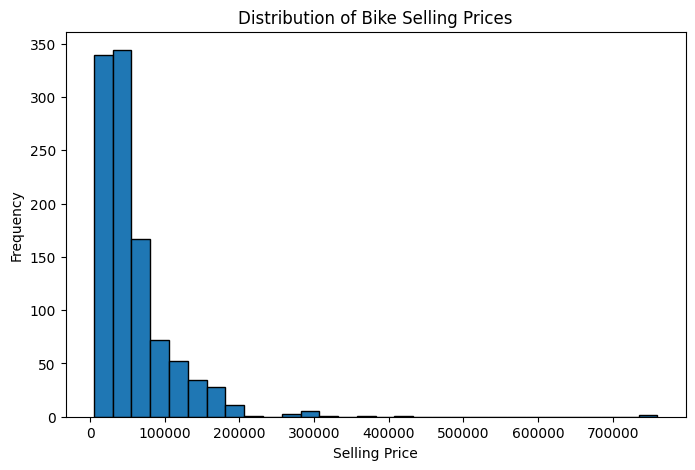

In [14]:
'''
Question 3: Plot the distribution of selling prices using a histogram and describe the
overall trend.
(Include your Python code and output in the code box below.)
'''

# Answer 3:
plt.figure(figsize=(8,5))
plt.hist(bike_df['selling_price'], bins=30, edgecolor='black')
plt.title("Distribution of Bike Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()



# Insight Observation:

# Selling prices are right-skewed — most bikes are in lower price ranges, with few expensive outliers.


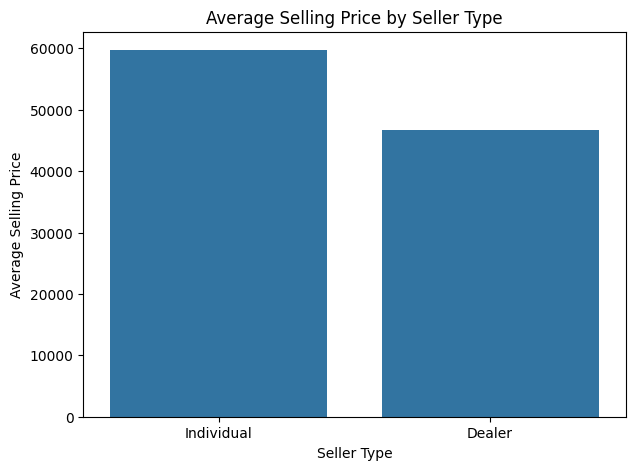

In [15]:
'''
Question 4: Create a bar plot to visualize the average selling price for each seller_type
and write one observation.
(Include your Python code and output in the code box below.)
'''

# Answer 4:

avg_price = bike_df.groupby('seller_type')['selling_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")
plt.show()


# Insight Observation:

# individual sellers generally have higher selling prices compared to Dealer sellers.

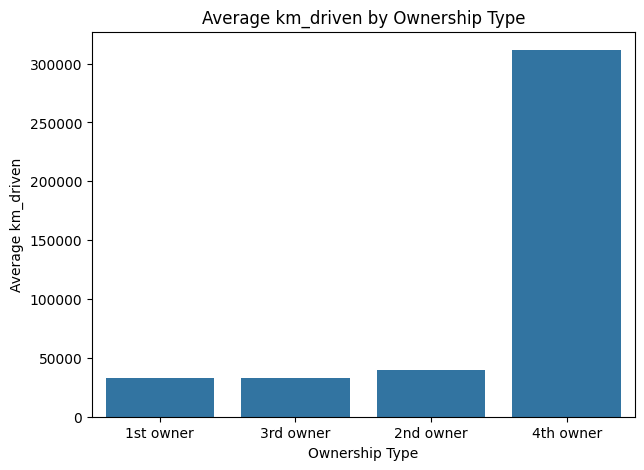

In [16]:
'''
Question 5: Compute the average km_driven for each ownership type (1st owner,
2nd owner, etc.), and present the result as a bar plot.
(Include your Python code and output in the code box below.)
'''

# Answer 5:

avg_km = bike_df.groupby('owner')['km_driven'].mean().sort_values()

plt.figure(figsize=(7,5))
sns.barplot(x=avg_km.index, y=avg_km.values)
plt.title("Average km_driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average km_driven")
plt.show()

Observation:

# 4th owners tend to have higher km_driven values compared to 1st, 2nd and 3rd owners.

In [20]:
'''
Question 6: Use the IQR method to detect and remove outliers from the km_driven
column. Show before-and-after summary statistics.
(Include your Python code and output in the code box below.)
'''

# Answer 6:

# Before removal
print("Before removing outliers:")
display(bike_df['km_driven'].describe())

# IQR method
Q1 = bike_df['km_driven'].quantile(0.25)
Q3 = bike_df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filter data
bike_df_no_outliers = bike_df[(bike_df['km_driven'] >= lower_limit) & (bike_df['km_driven'] <= upper_limit)]

print('\n-----------------------------------------------------------------------------\n')
print("\nAfter removing outliers:")
display(bike_df_no_outliers['km_driven'].describe())

print('\n-----------------------------------------------------------------------------\n')
print(f"\nRows before: {len(bike_df)}, after: {len(bike_df_no_outliers)}")


Before removing outliers:


,km_driven
count,1061.000000
mean,34359.833176
std,51623.152702
min,350.000000
25%,13500.000000
50%,25000.000000
75%,43000.000000
max,880000.000000



-----------------------------------------------------------------------------


After removing outliers:


,km_driven
count,1022.000000
mean,28203.415851
std,19552.083583
min,350.000000
25%,13000.000000
50%,24000.000000
75%,40000.000000
max,86000.000000



-----------------------------------------------------------------------------


Rows before: 1061, after: 1022


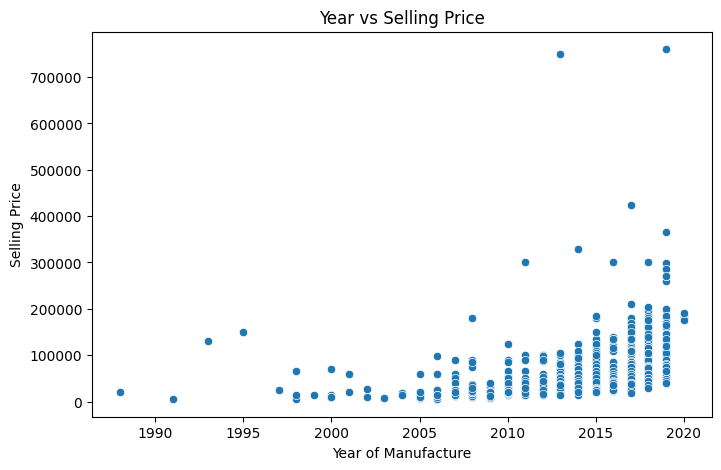

In [21]:
'''
Question 7: Create a scatter plot of year vs. selling_price to explore the
relationship between a bike's age and its price.
(Include your Python code and output in the code box below.)
'''

# Answer 7:

plt.figure(figsize=(8,5))
sns.scatterplot(x='year', y='selling_price', data=bike_df_no_outliers)
plt.title("Year vs Selling Price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price")
plt.show()

# Insight Observation:

# Newer bikes tend to have higher selling prices, showing a clear negative correlation between bike's age and price.

In [29]:
'''
Question 8: Convert the seller_type column into numeric format using one-hot
encoding. Display the first 5 rows of the resulting DataFrame.
(Include your Python code and output in the code box below.)
'''

# Answer 8:

bike_encoded = pd.get_dummies(bike_df_no_outliers, columns=['seller_type'], drop_first=False)
bike_encoded.head()


,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Dealer,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350,72752.5,False,True
1,Honda Dio,45000,2017,1st owner,5650,72752.5,False,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,False,True
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,False,True
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000,72752.5,False,True


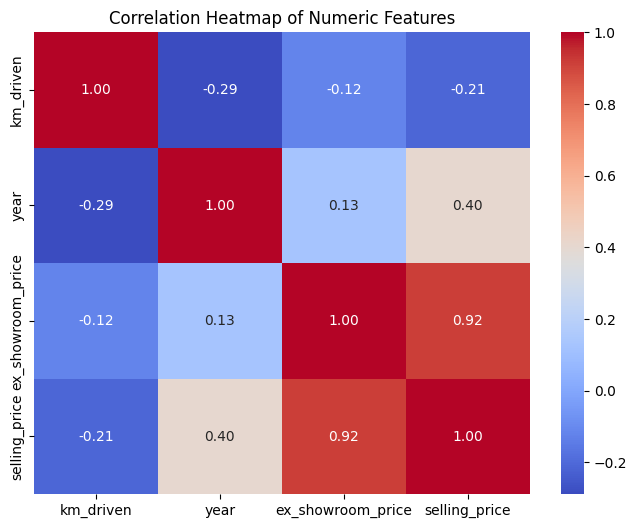

In [33]:
'''
Question 9: Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?
(Include your Python code and output in the code box below.)
'''

# Answer 9:

numeric_cols = ['km_driven','year', 'ex_showroom_price', 'selling_price']


plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

#Observation:

#Selling Price is positively correlated with year and ex_showroom_price.
# Selling Price is negatively correlated with km_driven and year.


**Question 10:** Summarize your findings in a brief report:
  1. What are the most important factors affecting a bike's selling price?
  2. Mention any data cleaning or feature engineering you performed.
(Include your Python code and output in the code box below.)

**Answer 10:**
  - Findings Report:

1. Most bikes are in the lower price range, showing a right-skewed price distribution.
2. Individuals-sold bikes generally have higher selling prices than those sold by Dealer.
3. 4th owners have higher average km_driven compared to 1st, 2nd and 3rd owner.
4. After removing outliers using IQR, data consistency improved.
5. There is a clear negative relationship between bike age and selling price.
6. Selling price correlates positively with year and ex_showroom_price.
7. Important factors affecting selling price:
   - Year of manufacture (newer bikes cost more)
   - Ex-showroom price (higher base value leads to higher resale)
   - Ownership type and km_driven (more usage decreases price)
8. Data cleaning included :
  - handling missing values,
  - removing outliers,
  - and encoding categorical variables.